### Bulk thermodynamics



We can predict temperature dependent thermodynamic properties of bulk materials without too much effort. As with the thermochemical properties of ideal gases, we must use some simple models that we parameterize by DFT. Here we follow the example in Reference citealp:Shang20101040 for computing the thermal coefficient of expansion, heat capacity, enthalpy and entropy for Ni as a function of temperature.

We start by computing the equation of state for fcc Ni.



Text(0, 0.5, 'Total energy (eV)')

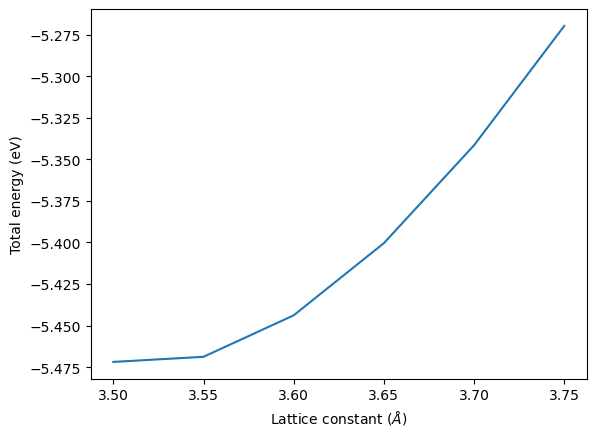

In [ ]:
from vasp import Vasp
from ase import Atom, Atoms
import numpy as np
# fcc
LC = [3.5, 3.55, 3.6, 3.65, 3.7, 3.75]
volumes, energies = [], []
for a in LC:
    atoms = Atoms([Atom('Ni', (0, 0, 0), magmom=2.5)],
                  cell=0.5 * a * np.array([[1.0, 1.0, 0.0],
                                           [0.0, 1.0, 1.0],
                                           [1.0, 0.0, 1.0]]))

    calc = Vasp(label='bulk/Ni-{0}'.format(a),
                xc='PBE',
                encut=350,
                kpts=(12, 12, 12),
                ispin=2,
                atoms=atoms)
    energies.append(calc.potential_energy)
    volumes.append(atoms.get_volume())

calc.stop_if(None in energies)

import matplotlib.pyplot as plt
plt.plot(LC, energies)
plt.xlabel('Lattice constant ($\AA$)')
plt.ylabel('Total energy (eV)');